In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Optional, Union
from matplotlib.colors import LinearSegmentedColormap

SHAP_DATA = "/Users/jwhite22/Desktop/marmoset-paper/modeling/results/feature_analysis/b_tp4_TP4_MeanHU_LoeweFIC90_cholesterol_Constant_20250612_shap_data.csv"
IN_VITRO_DATA = "/Users/jwhite22/Desktop/marmoset-paper/data/in_vitro_diamond_data.csv"
SEED = 42

COMPOUND_COLORS = {
    # 2-drug combinations
    'BDQ+DEL': '#4E79A7',  # blue
    'BDQ+LIN': '#F28E2B',  # orange
    'BDQ+PRE': '#E15759',  # red
    'INH+PZA': '#76B7B2',  # teal
    'LIN+PRE': '#59A14F',  # green
    'MOX+RIF': '#EDC948',  # yellow
    'PZA+RIF': '#B07AA1',  # purple
    # 3-drug combinations
    'BDQ+LIN+PRE': '#FF9DA7',  # light red
    # 4-drug combinations
    'EMB+INH+PZA+RIF': '#9C755F',  # brown
    'EMB+MOX+PZA+RIF': '#BAB0AC',  # gray
}

COMPOUND_NAMES = {
    'BDQ+DEL': "BD",
    'BDQ+LIN': "BL",
    'BDQ+PRE': "BPa",
    'INH+PZA': "HZ",
    'LIN+PRE': "PaL",
    'MOX+RIF': "MR",
    'PZA+RIF': "PR",
    'BDQ+LIN+PRE': "BPaL",
    'EMB+INH+PZA+RIF': "HZRE",
    'EMB+MOX+PZA+RIF': "MRZE",
}

np.random.seed(SEED)

In [2]:
shap_data = pd.read_csv(SHAP_DATA)
in_vitro_data = pd.read_csv(IN_VITRO_DATA)

shap_data.head()

,sample_id,feature_name,feature_value,shap_value
0,0,LoeweFIC90_cholesterol_Constant,0.088213,-0.327750
1,1,LoeweFIC90_cholesterol_Constant,0.088213,-0.304230
2,2,LoeweFIC90_cholesterol_Constant,0.088213,-0.330739
3,3,LoeweFIC90_cholesterol_Constant,0.088213,-0.980561
4,4,LoeweFIC90_cholesterol_Constant,0.088213,-0.340853


In [3]:
def merge_data(
    shap_df: pd.DataFrame,
    in_vitro_df: pd.DataFrame,
    drug_col: str = 'Drug',
    feature_col: str = 'feature_name',
    value_col: str = 'feature_value'
) -> pd.DataFrame:
    """
    Merges a SHAP DataFrame (with columns 'feature_name','feature_value')
    and an in vitro wide-format DataFrame (with one Drug column and
    feature columns), returning a DataFrame enriched with 'Drug'.

    Parameters:
    - shap_df: DataFrame with ['feature_name','feature_value','shap_value',...]
    - in_vitro_df: wide-format DataFrame with a Drug column and feature columns
    - drug_col: name of the drug column in in_vitro_df
    - feature_col: name for the melted feature column (matches shap_df)
    - value_col: name for the melted value column (matches shap_df)

    Returns:
    - merged_df: DataFrame containing all SHAP rows plus 'Drug'
    """
    # melt in vitro wide -> long
    if drug_col not in in_vitro_df.columns:
        raise KeyError(f"'{drug_col}' not found in in vitro DataFrame")

    id_vars = [drug_col]
    melt_df = in_vitro_df.melt(
        id_vars=id_vars,
        var_name=feature_col,
        value_name=value_col
    )

    # merge on feature_name and feature_value
    merged_df = shap_df.merge(
        melt_df,
        on=[feature_col, value_col],
        how='left'
    )
    return merged_df

In [4]:
merged = merge_data(shap_data, in_vitro_data)
merged.head()

,sample_id,feature_name,feature_value,shap_value,Drug
0,0,LoeweFIC90_cholesterol_Constant,0.088213,-0.327750,BDQ+DEL
1,1,LoeweFIC90_cholesterol_Constant,0.088213,-0.304230,BDQ+DEL
2,2,LoeweFIC90_cholesterol_Constant,0.088213,-0.330739,BDQ+DEL
3,3,LoeweFIC90_cholesterol_Constant,0.088213,-0.980561,BDQ+DEL
4,4,LoeweFIC90_cholesterol_Constant,0.088213,-0.340853,BDQ+DEL


In [5]:
# Create a modified 'vlag' colormap with a light grey center
_base = plt.get_cmap('vlag')(np.linspace(0, 1, 256))
_center = np.array([0.85, 0.85, 0.85, 1.0])  # light grey RGBA
_base[128] = _center
VLG = LinearSegmentedColormap.from_list('vlag_grey_center', _base)

In [ ]:
def plot_shap_feature(
    df: pd.DataFrame,
    feature_name: str,
    color_by_value: bool = True,
    highlight_compound: Optional[str] = None,
    save_path: Optional[Union[str, Path]] = None,
    save_format: str = 'png',
    dpi: int = 300
) -> None:
    np.random.seed(42)
    plot_df = df.copy()
    jitter = np.random.normal(0, 0.08, len(plot_df))
    plt.figure(figsize=(8, 2))
    if color_by_value:
        sc = plt.scatter(
            plot_df['shap_value'], jitter,
            c=plot_df['feature_value'], cmap=VLG, alpha=0.9, s=30
        )
        plt.colorbar(sc, label=feature_name)
    else:
        plt.scatter(
            plot_df['shap_value'], jitter,
            color='lightgrey', alpha=0.6, s=50
        )
        if highlight_compound:
            color = COMPOUND_COLORS.get(highlight_compound, 'black')
            name = COMPOUND_NAMES.get(highlight_compound, highlight_compound)
            mask = plot_df['Drug'] == highlight_compound
            plt.scatter(
                plot_df.loc[mask, 'shap_value'], jitter[mask],
                facecolors=color, edgecolors=color, s=50,
                linewidths=1.5, label=name
            )
            plt.legend()
    plt.xlabel('SHAP value')
    plt.yticks([])
    plt.title(f"SHAP for {feature_name}")
    plt.axvline(0, color='black', linestyle='--', linewidth=1)
    plt.tight_layout()
    if save_path:
        p = Path(save_path)
        if p.is_dir():
            fname = feature_name + (f"_highlight_{highlight_compound}" if highlight_compound else '') + f".{save_format}"
            f = p / fname
        else:
            f = p
        plt.savefig(f, dpi=dpi, bbox_inches='tight', format=save_format)
        print(f"Saved plot to {f}")
        plt.close()
    else:
        plt.show()


ValueError: x and y must be the same size

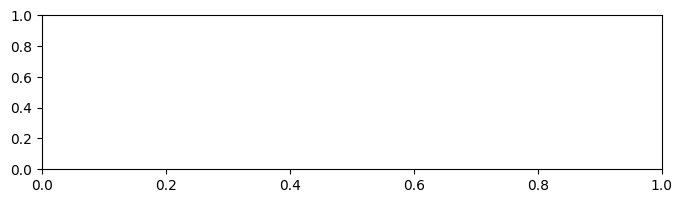

In [8]:
plot_shap_feature(merged, feature_name="LoeweFIC90_cholesterol_Constant", color_by_value=True)

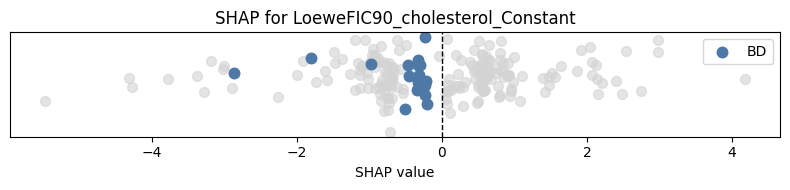

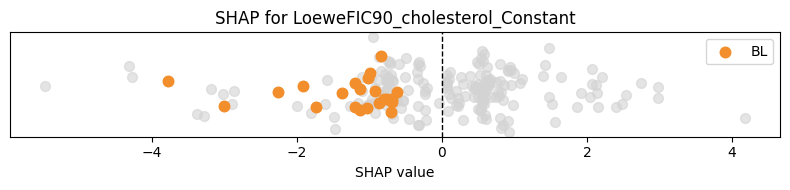

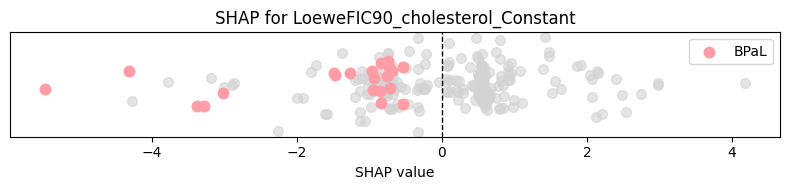

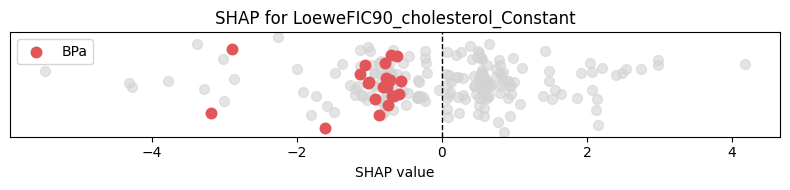

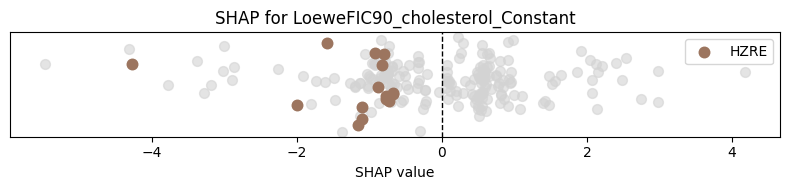

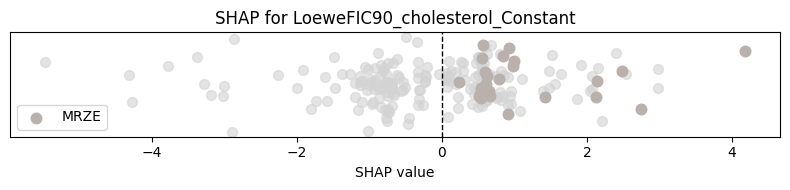

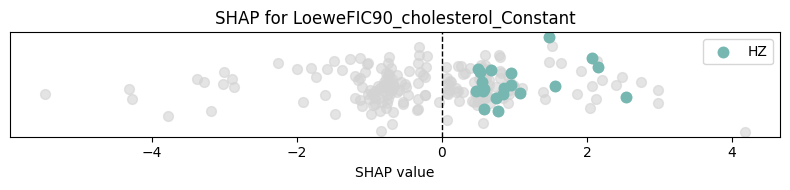

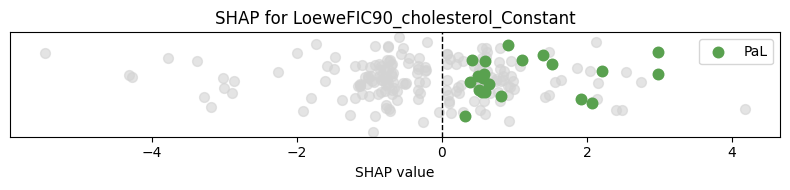

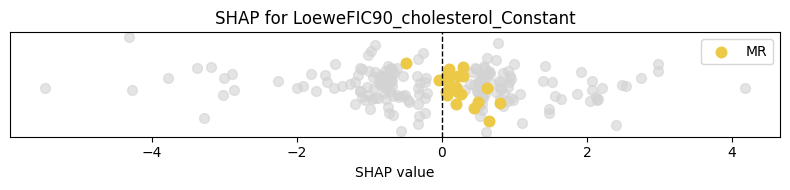

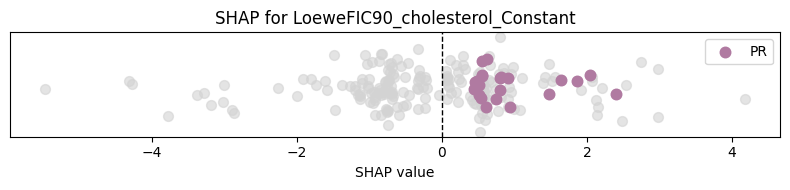

In [ ]:
for d in merged['Drug'].unique().tolist():
    plot_shap_feature(merged, feature_name="LoeweFIC90_cholesterol_Constant", color_by_value=False, highlight_compound=d)

In [ ]:
def plot_shap_stacked(
    df: pd.DataFrame,
    feature_name: str,
    save_path: Union[str, Path],
    save_format: str = 'svg',
    dpi: int = 300
) -> None:
    drugs = df['Drug'].dropna().unique().tolist()
    n = len(drugs)
    fig, axes = plt.subplots(n, 1, figsize=(8, 2*(n+1)), sharex=True)
    
    for ax, drug in zip(axes, drugs):
        plt.sca(ax)
        plot_df = df.copy()
        jitter = np.random.normal(0, 0.08, len(plot_df))
        plt.scatter(
            plot_df['shap_value'], jitter,
            color='lightgrey', alpha=0.6, s=50
        )
        plt.scatter(
            plot_df.loc[plot_df['Drug'] == drug, 'shap_value'],
            jitter[plot_df['Drug'] == drug],
            facecolors=COMPOUND_COLORS.get(drug, 'black'),
            edgecolors=COMPOUND_COLORS.get(drug, 'black'),
            s=50, linewidths=1.5
        )
        plt.axvline(0, color='black', linestyle='--', linewidth=1)
        ax.set_ylabel(drug)
        ax.set_yticks([])
    axes[-1].set_xlabel('SHAP value')
    plt.suptitle(f"Stacked SHAP for {feature_name}")
    plt.tight_layout(rect=[0, 0.03, 1, 0.9  5])
    out = Path(save_path)
    out.mkdir(parents=True, exist_ok=True)
    fpath = out / f"stacked_{feature_name}.{save_format}"
    fig.savefig(fpath, dpi=dpi, format=save_format)
    print(f"Saved stacked figure to {fpath}")
    plt.close(fig)

SyntaxError: invalid syntax (1836988264.py, line 32)

In [ ]:
plot_shap_stacked(merged, feature_name="LoeweFIC90_cholesterol_Constant", save_path="SHAP_figures", save_format="svg")


Saved stacked figure to SHAP_figures/stacked_LoeweFIC90_cholesterol_Constant.svg
